In [58]:
import os
os.getcwd()
os.listdir()

['analysis.ipynb',
 'data_dictionary.csv',
 'transfermarkt_player_values.csv',
 'transfermarkt_player_values.parquet',
 'transfermarkt_value_history.csv']

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [60]:
df = pd.read_csv("transfermarkt_player_values.csv", engine ="python")


In [61]:
df.columns = [
'player_id','name','age','nationality','market_value','position_group',
'current_club','league_name','current_value_eur','current_value_tier',
'peak_value_eur','peak_value_tier','peak_date','peak_club',
'age_at_peak','first_value_eur','first_date','last_value_eur','last_date',
'career_span_years','years_to_peak','value_cagr','value_to_peak_cagr',
'value_multiplier_x','post_peak_decline_pct','value_volatility',
'mean_yoy_growth_rate','num_valuation_points','num_clubs_career',
'trajectory','is_at_peak','ever_100m','ever_50m','ever_10m','data_source','dataset_built_at'
]

In [62]:
df.head(10)

,player_id,name,age,nationality,market_value,position_group,current_club,league_name,current_value_eur,current_value_tier,...,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,trajectory,is_at_peak,ever_100m,ever_50m,ever_10m,data_source,dataset_built_at
0,418560,Erling Haaland,25.0,Norway,€200.00m,Other,Norway,Premier League,200000000.0,World Class (100M+),...,1.6329,26,5,growing,0,1,1,1,Transfermarkt.com,2026-02-21
1,433177,Bukayo Saka,24.0,England,€130.00m,Other,England,Premier League,130000000.0,World Class (100M+),...,0.6972,22,1,growing,0,1,1,1,Transfermarkt.com,2026-02-21
2,357662,Declan Rice,27.0,England,€120.00m,Other,England,Premier League,120000000.0,World Class (100M+),...,1.6100,24,2,growing,0,1,1,1,Transfermarkt.com,2026-02-21
3,568177,Cole Palmer,23.0,England,€120.00m,Other,England,Premier League,120000000.0,World Class (100M+),...,2.0823,15,3,growing,0,1,1,1,Transfermarkt.com,2026-02-21
4,349066,Alexander Isak,26.0,Sweden,€120.00m,Other,Sweden,Premier League,120000000.0,World Class (100M+),...,1.5154,28,6,growing,0,1,1,1,Transfermarkt.com,2026-02-21
5,687626,Moisés Caicedo,24.0,Ecuador,€110.00m,Other,Ecuador,Premier League,110000000.0,World Class (100M+),...,3.6285,19,4,rising_star,1,1,1,1,Transfermarkt.com,2026-02-21
6,598577,Florian Wirtz,22.0,Germany,€110.00m,Other,Germany,Premier League,110000000.0,World Class (100M+),...,0.6744,17,2,stable,0,1,1,1,Transfermarkt.com,2026-02-21
7,495666,William Saliba,24.0,France,€90.00m,Other,France,Premier League,90000000.0,Elite (50-100M),...,0.6991,22,4,rising_star,1,0,1,1,Transfermarkt.com,2026-02-21
8,478573,Ryan Gravenberch,23.0,Netherlands,€90.00m,Other,Netherlands,Premier League,90000000.0,Elite (50-100M),...,0.8715,24,4,growing,0,0,1,1,Transfermarkt.com,2026-02-21
9,648195,Enzo Fernández,25.0,Argentina,€85.00m,Other,Argentina,Premier League,85000000.0,Elite (50-100M),...,1.3327,16,4,growing,0,0,1,1,Transfermarkt.com,2026-02-21


In [63]:
df.tail(10)

,player_id,name,age,nationality,market_value,position_group,current_club,league_name,current_value_eur,current_value_tier,...,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,trajectory,is_at_peak,ever_100m,ever_50m,ever_10m,data_source,dataset_built_at
498,557613,Quentin Merlin,23.0,France,€12.00m,Other,France,Ligue 1,12000000.0,Regular (5-20M),...,1.5730,14,4,stable,0,0,0,1,Transfermarkt.com,2026-02-21
499,739769,Ilan Kebbal,27.0,Algeria,€12.00m,Other,Algeria,Ligue 1,12000000.0,Regular (5-20M),...,1.0758,16,3,rising_star,1,0,0,1,Transfermarkt.com,2026-02-21
500,414908,Marshall Munetsi,29.0,Zimbabwe,€12.00m,Other,Zimbabwe,Ligue 1,12000000.0,Regular (5-20M),...,0.9016,25,5,stable,0,0,0,1,Transfermarkt.com,2026-02-21
501,190393,Corentin Tolisso,31.0,France,€12.00m,Other,France,Ligue 1,12000000.0,Regular (5-20M),...,0.6968,33,2,falling_sharply,0,0,0,1,Transfermarkt.com,2026-02-21
502,670847,Mohamed-Ali Cho,22.0,France,€12.00m,Other,France,Ligue 1,12000000.0,Regular (5-20M),...,0.9933,19,3,stable,0,0,0,1,Transfermarkt.com,2026-02-21
503,569389,Sofiane Diop,25.0,Morocco,€10.00m,Other,Morocco,Ligue 1,10000000.0,Regular (5-20M),...,0.5238,22,3,declining,0,0,0,1,Transfermarkt.com,2026-02-21
504,532775,Melvin Bard,25.0,France,€10.00m,Other,France,Ligue 1,10000000.0,Regular (5-20M),...,1.0349,14,2,declining,0,0,0,1,Transfermarkt.com,2026-02-21
505,191056,Brice Samba,31.0,France,€10.00m,Other,France,Ligue 1,10000000.0,Regular (5-20M),...,0.8062,38,7,declining,0,0,0,1,Transfermarkt.com,2026-02-21
506,548254,Nathan Ngoy,22.0,Belgium,€10.00m,Other,Belgium,Ligue 1,10000000.0,Regular (5-20M),...,1.5560,15,3,rising_star,1,0,0,1,Transfermarkt.com,2026-02-21
507,580657,Osame Sahraoui,24.0,Morocco,€10.00m,Other,Morocco,Ligue 1,10000000.0,Regular (5-20M),...,1.1957,12,3,growing,0,0,0,1,Transfermarkt.com,2026-02-21


In [64]:
df.shape

(508, 36)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   player_id              508 non-null    int64  
 1   name                   508 non-null    object 
 2   age                    501 non-null    float64
 3   nationality            501 non-null    object 
 4   market_value           508 non-null    object 
 5   position_group         508 non-null    object 
 6   current_club           508 non-null    object 
 7   league_name            508 non-null    object 
 8   current_value_eur      508 non-null    float64
 9   current_value_tier     508 non-null    object 
 10  peak_value_eur         508 non-null    int64  
 11  peak_value_tier        508 non-null    object 
 12  peak_date              508 non-null    object 
 13  peak_club              508 non-null    object 
 14  age_at_peak            508 non-null    int64  
 15  first_

In [66]:
df.describe()

,player_id,age,current_value_eur,peak_value_eur,age_at_peak,first_value_eur,last_value_eur,career_span_years,years_to_peak,value_cagr,...,value_multiplier_x,post_peak_decline_pct,value_volatility,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,is_at_peak,ever_100m,ever_50m,ever_10m
count,5.080000e+02,501.000000,5.080000e+02,5.080000e+02,508.000000,5.080000e+02,5.080000e+02,508.000000,508.000000,508.000000,...,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000
mean,5.696943e+05,26.245509,3.686693e+07,4.470256e+07,22.944882,1.019390e+06,3.686693e+07,6.447421,5.123839,31.168225,...,285.736575,14.792795,0.830600,2.632739,19.220472,3.643701,0.230315,0.059055,0.354331,0.992126
std,2.369518e+05,6.176213,2.770602e+07,3.136733e+07,2.594356,2.498742e+06,2.770602e+07,3.002012,2.433462,517.286646,...,432.601177,19.851034,0.291926,3.871000,7.863895,1.470626,0.421449,0.235960,0.478781,0.088473
min,1.083900e+05,15.000000,3.000000e+05,3.000000e+05,17.000000,2.500000e+04,3.000000e+05,0.210000,0.210000,0.072900,...,3.000000,0.000000,0.281900,0.051900,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.939142e+05,22.000000,2.000000e+07,2.200000e+07,21.000000,1.000000e+05,2.000000e+07,4.295000,3.232500,0.676150,...,50.000000,0.000000,0.615725,1.013825,13.000000,3.000000,0.000000,0.000000,0.000000,1.000000
50%,5.372165e+05,25.000000,2.800000e+07,3.500000e+07,23.000000,2.500000e+05,2.800000e+07,6.160000,4.870000,1.102400,...,140.000000,0.000000,0.773850,1.554500,19.000000,3.000000,0.000000,0.000000,0.000000,1.000000
75%,7.094605e+05,29.000000,4.500000e+07,6.000000e+07,25.000000,7.500000e+05,4.500000e+07,8.480000,6.730000,1.951800,...,333.330000,25.000000,0.987200,2.702975,25.000000,4.000000,0.000000,0.000000,1.000000,1.000000
max,1.390649e+06,45.000000,2.000000e+08,2.000000e+08,30.000000,2.500000e+07,2.000000e+08,16.540000,12.330000,11521.554400,...,4000.000000,83.000000,1.920000,36.263700,45.000000,11.000000,1.000000,1.000000,1.000000,1.000000


In [67]:
df.isnull().sum()

player_id                0
name                     0
age                      7
nationality              7
market_value             0
position_group           0
current_club             0
league_name              0
current_value_eur        0
current_value_tier       0
peak_value_eur           0
peak_value_tier          0
peak_date                0
peak_club                0
age_at_peak              0
first_value_eur          0
first_date               0
last_value_eur           0
last_date                0
career_span_years        0
years_to_peak            0
value_cagr               0
value_to_peak_cagr       0
value_multiplier_x       0
post_peak_decline_pct    0
value_volatility         0
mean_yoy_growth_rate     0
num_valuation_points     0
num_clubs_career         0
trajectory               0
is_at_peak               0
ever_100m                0
ever_50m                 0
ever_10m                 0
data_source              0
dataset_built_at         0
dtype: int64

In [68]:
df['nationality'].fillna("Unknown", inplace = True)

C:\Users\mantu\AppData\Local\Temp\ipykernel_6960\4072322006.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['nationality'].fillna("Unknown", inplace = True)


In [69]:
df['age'] = df['age'].fillna(df['age'].mean())

In [70]:
df.sort_values('current_value_eur', ascending=False)

,player_id,name,age,nationality,market_value,position_group,current_club,league_name,current_value_eur,current_value_tier,...,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,trajectory,is_at_peak,ever_100m,ever_50m,ever_10m,data_source,dataset_built_at
0,418560,Erling Haaland,25.000000,Norway,€200.00m,Other,Norway,Premier League,200000000.0,World Class (100M+),...,1.6329,26,5,growing,0,1,1,1,Transfermarkt.com,2026-02-21
103,342229,Kylian Mbappé,27.000000,France,€200.00m,Other,France,La Liga,200000000.0,World Class (100M+),...,2.4610,30,4,growing,0,1,1,1,Transfermarkt.com,2026-02-21
104,937958,Lamine Yamal,18.000000,Spain,€200.00m,Other,Spain,La Liga,200000000.0,World Class (100M+),...,1.6822,10,1,growing,0,1,1,1,Transfermarkt.com,2026-02-21
105,581678,Jude Bellingham,22.000000,England,€160.00m,Other,England,La Liga,160000000.0,World Class (100M+),...,1.1054,20,3,growing,0,1,1,1,Transfermarkt.com,2026-02-21
106,371998,Vinicius Junior,25.000000,Brazil,€150.00m,Other,Brazil,La Liga,150000000.0,World Class (100M+),...,0.9397,24,2,stable,0,1,1,1,Transfermarkt.com,2026-02-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,580657,Osame Sahraoui,24.000000,Morocco,€10.00m,Other,Morocco,Ligue 1,10000000.0,Regular (5-20M),...,1.1957,12,3,growing,0,0,0,1,Transfermarkt.com,2026-02-21
128,533354,Facundo Garcés,26.245509,Unknown,€1.00m,Other,Deportivo Alavés,La Liga,1000000.0,Developing (<5M),...,4.0949,17,3,falling_sharply,0,0,0,0,Transfermarkt.com,2026-02-21
129,1124136,Ángel Pérez,26.245509,Unknown,€600k,Other,Deportivo Alavés,La Liga,600000.0,Developing (<5M),...,2.1408,8,3,rising_star,1,0,0,0,Transfermarkt.com,2026-02-21
130,1063574,Jan Salas,26.245509,Unknown,€500k,Other,RCD Mallorca,La Liga,500000.0,Developing (<5M),...,3.7180,5,2,growing,0,0,0,0,Transfermarkt.com,2026-02-21


In [71]:
df['current_value_eur']= pd.to_numeric(df['current_value_eur'], errors = 'coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

League Value

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Premier League'),
  Text(1, 0, 'La Liga'),
  Text(2, 0, 'Bundesliga'),
  Text(3, 0, 'Serie A'),
  Text(4, 0, 'Ligue 1')])

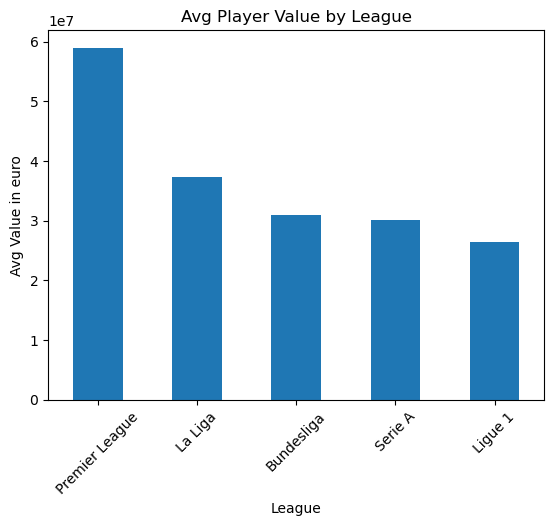

In [72]:
df.groupby('league_name')['current_value_eur'].mean().sort_values(ascending=False).plot(kind='bar')

plt.title("Avg Player Value by League")
plt.xlabel("League")
plt.ylabel("Avg Value in euro")
plt.xticks(rotation=45)

Insight
Premier League has the highest average player value, showing its financial dominance.

worth more than 50m

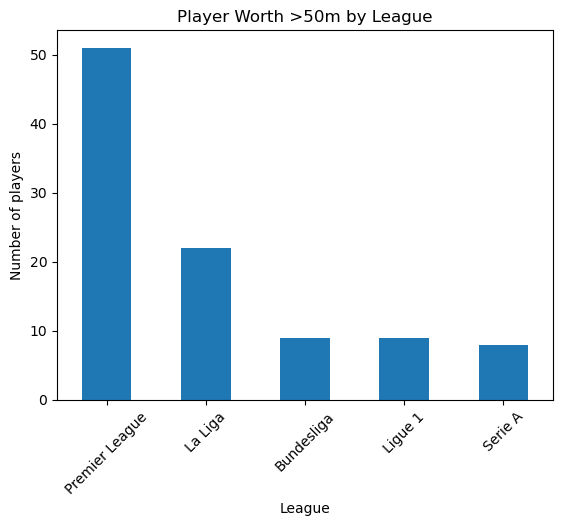

In [73]:
df[df['current_value_eur'] > 50000000].groupby('league_name').size().sort_values(ascending=False).plot(kind='bar')

plt.title("Player Worth >50m by League")
plt.xlabel("League")
plt.ylabel("Number of players")
plt.xticks(rotation = 45)
plt.show()

Insight
Premier League dominates in high-value players, indicating stronger investment and competition.

In [74]:
df.groupby('nationality').size().sort_values(ascending=False)

nationality
Spain       59
France      57
England     39
Germany     39
Brazil      34
            ..
Mali         1
Romania      1
Mexico       1
Poland       1
Zimbabwe     1
Length: 61, dtype: int64

Insight
Spain and France have the highest number of players, indicating strong football talent development systems.

In [75]:
df.groupby('nationality')['current_value_eur'].mean().sort_values(ascending=False)

nationality
Ecuador      7.666667e+07
Egypt        6.500000e+07
Norway       6.450000e+07
Hungary      6.250000e+07
Georgia      5.900000e+07
                 ...     
Mali         1.500000e+07
Venezuela    1.500000e+07
Poland       1.200000e+07
Zimbabwe     1.200000e+07
Unknown      1.005714e+07
Name: current_value_eur, Length: 61, dtype: float64

Insight
Some countries have fewer players but higher average value, indicating quality over quantity.

In [76]:
df.groupby('nationality')['current_value_eur'].agg(['mean', 'max']).sort_values(by='mean', ascending=False)

,mean,max
nationality,,
Ecuador,7.666667e+07,110000000.0
Egypt,6.500000e+07,65000000.0
Norway,6.450000e+07,200000000.0
Hungary,6.250000e+07,85000000.0
Georgia,5.900000e+07,90000000.0
...,...,...
Mali,1.500000e+07,15000000.0
Venezuela,1.500000e+07,15000000.0
Poland,1.200000e+07,12000000.0


In [77]:
df.groupby('league_name')['current_value_eur'].agg(['max', 'mean']).sort_values(by='mean', ascending=False)

,max,mean
league_name,,
Premier League,200000000.0,5.899029e+07
La Liga,200000000.0,3.728269e+07
Bundesliga,130000000.0,3.093000e+07
Serie A,85000000.0,3.015842e+07
Ligue 1,110000000.0,2.636000e+07


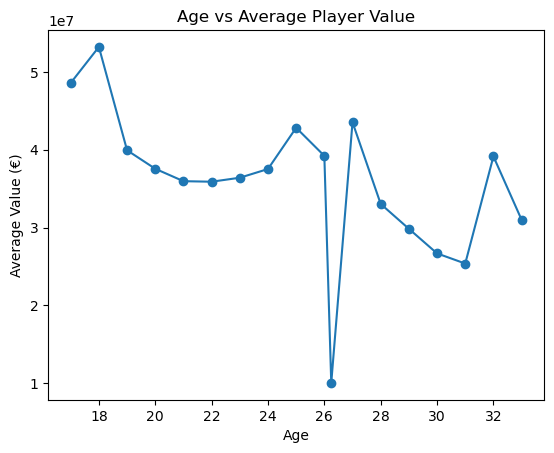

In [85]:
temp = df.groupby('age')['current_value_eur'].agg(count = 'count', mean = 'mean')
temp = temp[temp['count'] > 5]

temp['mean'].plot(kind='line', marker = 'o')

plt.title("Age vs Average Player Value")
plt.xlabel("Age")
plt.ylabel("Average Value (€)")

plt.show()

Insight
Player value peaks around mid-20s, showing prime performance age.

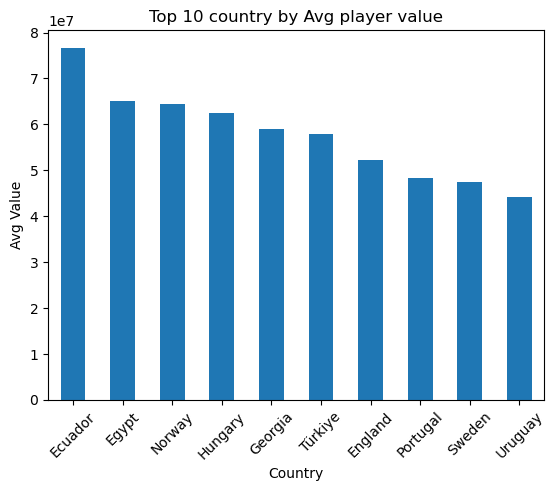

In [79]:
df.groupby('nationality')['current_value_eur'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 country by Avg player value")
plt.xlabel("Country")
plt.ylabel("Avg Value")
plt.xticks(rotation = 45)
plt.show()

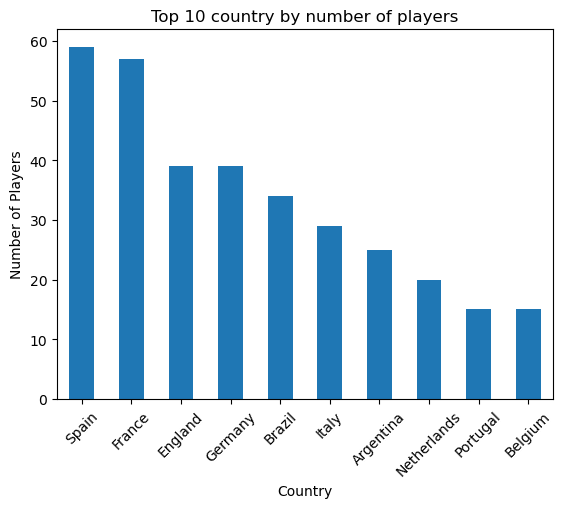

In [80]:
nat = df.groupby('nationality')['name'].size().sort_values(ascending=False).head(10).plot(kind = 'bar')

plt.title("Top 10 country by number of players")
plt.xlabel("Country")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)

plt.show()

histogram

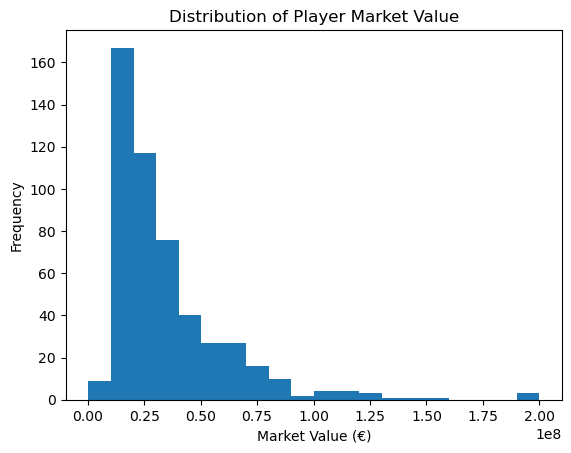

In [81]:
df['current_value_eur'].plot(kind='hist', bins=20)

plt.title("Distribution of Player Market Value")
plt.xlabel("Market Value (€)")
plt.ylabel("Frequency")

plt.show()